## НИР. 2 семестр
# Метод распознавания составных эмоций по мимике лица на основе базовых эмоциональных состояний
## Гусева Надежда Леонидовна, М4121

In [2]:
import os
import gc 
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
import optuna
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50V2, ResNet101V2, ResNet152V2
from sklearn.metrics import f1_score, hamming_loss, accuracy_score, precision_score, recall_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

/home/guseva-n@ad.speechpro.com/dsp/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 1. ПУТИ И НАСТРОЙКИ

# Убираем лишние предупреждения TensorFlow для чистоты вывода
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# 112x112 - нет GPU и мало оперативки, уменьшаю размер картинок
INPUT_SIZE = 112 

dataset_path = '/home/guseva-n@ad.speechpro.com/dsp/НИР/2 семестр/Датасеты/RAF_ML_Extract'
multilabel_path = os.path.join(dataset_path, 'EmoLabel', 'multilabel.txt')
partition_path = os.path.join(dataset_path, 'EmoLabel', 'partition_label.txt')
image_dir = os.path.join(dataset_path, 'Image', 'aligned')

BASIC_NAMES = ["Surprise", "Fear", "Disgust", "Happiness", "Sadness", "Anger"]

# Маппинг составных эмоций
COMPOUND_MAP = {
    'Happily Surprised': [3, 0],      # Радость + Удивление
    'Happily Disgusted': [3, 2],      # Радость + Отвращение
    'Sadly Fearful': [4, 1],          # Грусть + Страх
    'Sadly Angry': [4, 5],            # Грусть + Гнев
    'Sadly Surprised': [4, 0],        # Грусть + Удивление
    'Sadly Disgusted': [4, 2],        # Грусть + Отвращение
    'Fearfully Angry': [1, 5],        # Страх + Гнев
    'Fearfully Surprised': [1, 0],    # Страх + Удивление
    'Angrily Surprised': [5, 0],      # Гнев + Удивление
    'Angrily Disgusted': [5, 2],      # Гнев + Отвращение
    'Disgustedly Surprised': [2, 0]   # Отвращение + Удивление
}

# 2. ЗАГРУЗКА ДАННЫХ

# Загрузка меток
labels_df = pd.read_csv(multilabel_path, sep=r'\s+', header=None)
labels_df.columns = ['filename'] + BASIC_NAMES
labels_df['filename'] = labels_df['filename'].astype(str).str.replace('.jpg', '', regex=False)
labels_df = labels_df.set_index('filename')

partition_df = pd.read_csv(partition_path, sep=r'\s+', header=None)
partition_df.columns = ['filename', 'partition']
partition_df['filename'] = partition_df['filename'].astype(str).str.replace('.jpg', '', regex=False)
partition_df = partition_df.set_index('filename')

common = labels_df.index.intersection(partition_df.index)
train_df = labels_df.loc[common][partition_df.loc[common]['partition'] == 0]
test_df  = labels_df.loc[common][partition_df.loc[common]['partition'] == 1]

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# Генерация Ground Truth для составных эмоций
def generate_compound_ground_truth(df_basic):
    df_compound = pd.DataFrame(index=df_basic.index)
    for compound_name, indices in COMPOUND_MAP.items():
        condition = 1
        for idx in indices:
            condition = condition & df_basic.iloc[:, idx]
        df_compound[compound_name] = condition.astype(int)
    return df_compound

y_train_compound = generate_compound_ground_truth(train_df)
y_test_compound  = generate_compound_ground_truth(test_df)
y_train_compound_arr = y_train_compound.values
y_test_compound_arr  = y_test_compound.values

# Функция загрузки изображений с автоматическим уменьшением размера
def load_images(df, image_dir, resize=(INPUT_SIZE, INPUT_SIZE)):
    X, y = [], []
    for idx in df.index:
        path = os.path.join(image_dir, f"{idx}_aligned.jpg")
        if os.path.exists(path):
            try:
                img = Image.open(path).convert("RGB").resize(resize)
                X.append(np.array(img) / 255.0)
                y.append(df.loc[idx].values)
            except:
                pass
    return np.array(X), np.array(y)

X_train, y_train_basic = load_images(train_df, image_dir)
X_test, y_test_basic   = load_images(test_df, image_dir)
print(f"Данные загружены. Размер: {X_train.shape}")

Train: 3926, Test: 982
Данные загружены. Размер: (3926, 112, 112, 3)


In [4]:
# Функция для очистки памяти между моделями
def clear_mem():
    gc.collect()
    tf.keras.backend.clear_session()

In [5]:
# 3. МОДЕЛИ

# 3.1. Binary Relevance
br_models = []
y_pred_br_test = np.zeros((len(X_test), 6))

for i in range(6):
    model = Sequential([
        Conv2D(32, 3, activation='relu', input_shape=(INPUT_SIZE, INPUT_SIZE, 3)),
        MaxPooling2D(),
        Conv2D(64, 3, activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    # batch_size уменьшен до 16 для экономии памяти
    model.fit(X_train, y_train_basic[:, i], epochs=10, batch_size=16, verbose=0)
    
    preds = model.predict(X_test, verbose=0).flatten()
    y_pred_br_test[:, i] = (preds > 0.5).astype(int)
    br_models.append(model)
    clear_mem()

W0000 00:00:1782435666.495467  116442 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
# 3.2. Neural Network (С Optuna + Гиперпараметры)

# Принудительная очистка памяти перед началом, ибо ядро падает

gc.collect()
tf.keras.backend.clear_session()

def objective(trial):
    # 1. Поиск гиперпараметров архитектуры
    filters_1 = trial.suggest_int('filters_1', 32, 128, step=32)
    filters_2 = trial.suggest_int('filters_2', 32, 128, step=32)
    dense_units = trial.suggest_int('dense_units', 128, 512, step=64)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    # Создаем модель
    model = Sequential([
        Conv2D(filters_1, (3, 3), activation='relu', input_shape=(INPUT_SIZE, INPUT_SIZE, 3)),
        MaxPooling2D(),
        Conv2D(filters_2, (3, 3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(6, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy')
    
    # Короткое обучение
    history = model.fit(X_train, y_train_basic, epochs=3, batch_size=16, 
                        validation_split=0.1, verbose=0)
    
    # после выхода из функции objective модель все еще в памяти
    # Но Optuna управляет своей копией, так что здесь мы просто возвращаем loss
    
    return history.history['val_loss'][-1]

# Запуск Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=False) # Скрыли прогресс-бар для экономии ресурсов

print("Лучшие параметры Optuna:", study.best_params)

# Перед созданием финальной модели очистка памяти
del model # Удаляем последнюю модель из Optuna, если она еще в scope
gc.collect()
tf.keras.backend.clear_session()

# Создание финальной модели с лучшими параметрами
best_lr = study.best_params['learning_rate']
best_filters_1 = study.best_params['filters_1']
best_filters_2 = study.best_params['filters_2']
best_dense = study.best_params['dense_units']
best_dropout = study.best_params['dropout_rate']

model_nn = Sequential([
    Conv2D(best_filters_1, (3, 3), activation='relu', input_shape=(INPUT_SIZE, INPUT_SIZE, 3)),
    MaxPooling2D(),
    Conv2D(best_filters_2, (3, 3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(best_dense, activation='relu'),
    Dropout(best_dropout),
    Dense(6, activation='sigmoid')
])

model_nn.compile(optimizer=Adam(learning_rate=best_lr), loss='binary_crossentropy', metrics=['accuracy'])

# Полное обучение лучшей модели
print("Начало обучения финальной модели...")
history_nn = model_nn.fit(X_train, y_train_basic, epochs=10, batch_size=16, 
                          validation_split=0.1, verbose=0)

# Прогноз
# Дополнительная очистка перед прогнозом, чтобы не упасть
gc.collect()
tf.keras.backend.clear_session()

y_pred_nn_prob = model_nn.predict(X_test, verbose=0)
y_pred_nn_test = (y_pred_nn_prob > 0.5).astype(int)

clear_mem()
print("Готово!")

[I 2026-06-26 06:21:38,515] A new study created in memory with name: no-name-69d459f6-3f20-45c6-a583-a8fa99d7beee
[I 2026-06-26 06:27:08,440] Trial 0 finished with value: 0.4850252568721771 and parameters: {'filters_1': 64, 'filters_2': 64, 'dense_units': 512, 'dropout_rate': 0.0251358210447869, 'learning_rate': 0.0001836268635957891}. Best is trial 0 with value: 0.4850252568721771.
[I 2026-06-26 06:31:29,610] Trial 1 finished with value: 0.49060094356536865 and parameters: {'filters_1': 64, 'filters_2': 96, 'dense_units': 256, 'dropout_rate': 0.08660456342168771, 'learning_rate': 0.001669057371770222}. Best is trial 0 with value: 0.4850252568721771.
[I 2026-06-26 06:38:39,238] Trial 2 finished with value: 0.4841521382331848 and parameters: {'filters_1': 96, 'filters_2': 128, 'dense_units': 320, 'dropout_rate': 0.07467556722024726, 'learning_rate': 0.000296852735467017}. Best is trial 2 with value: 0.4841521382331848.
[I 2026-06-26 06:42:21,613] Trial 3 finished with value: 0.503122985

Лучшие параметры Optuna: {'filters_1': 32, 'filters_2': 128, 'dense_units': 384, 'dropout_rate': 0.3639797119339802, 'learning_rate': 0.0004144973738543159}
Начало обучения финальной модели...
Готово!


In [ ]:
# 3.3. Classifier Chains
print("\n--- 3. Classifier Chains (Memory Optimized) ---")
print("Очистка памяти перед запуском...")
gc.collect()
tf.keras.backend.clear_session()

# ИСПРАВЛЕНИЕ: Временно уменьшаем размер картинок ТОЛЬКО для этого алгоритма,
# чтобы ноутбук не вылетел из-за нехватки оперативной памяти.
CHAIN_SIZE = 64 
print(f"Сжатие изображений до {CHAIN_SIZE}x{CHAIN_SIZE} специально для Classifier Chains...")
X_train_ch = tf.image.resize(X_train, (CHAIN_SIZE, CHAIN_SIZE)).numpy()
X_test_ch = tf.image.resize(X_test, (CHAIN_SIZE, CHAIN_SIZE)).numpy()

chain_models = []
chain_test_preds = []
chain_train_preds = [] 

for i in range(6):
    print(f"Шаг цепи {i+1}/6...")
    
    if i == 0:
        # Используем уменьшенную картинку
        X_aug_train = X_train_ch
        X_aug_test = X_test_ch
        input_shape = (CHAIN_SIZE, CHAIN_SIZE, 3)
    else:
        # Создаем стопку каналов. dtype=np.float32 экономит память в 2 раза
        preds_stack = np.zeros((X_train_ch.shape[0], CHAIN_SIZE, CHAIN_SIZE, i), dtype=np.float32)
        
        for j in range(i):
            # ИСПРАВЛЕНИЕ: Используем np.resize и принудительно float32
            preds_reshaped = np.resize(chain_train_preds[j], (X_train_ch.shape[0], CHAIN_SIZE, CHAIN_SIZE)).astype(np.float32)
            preds_stack[:, :, :, j] = preds_reshaped
            del preds_reshaped # Удаляем сразу после использования
            
        X_aug_train = np.concatenate([X_train_ch, preds_stack], axis=3)
        
        X_aug_test = np.zeros((X_test_ch.shape[0], CHAIN_SIZE, CHAIN_SIZE, 3+i), dtype=np.float32)
        X_aug_test[:, :, :, :3] = X_test_ch
        
        for j, pred in enumerate(chain_test_preds):
             preds_reshaped_test = np.resize(pred, (X_test_ch.shape[0], CHAIN_SIZE, CHAIN_SIZE)).astype(np.float32)
             X_aug_test[:, :, :, 3+j] = preds_reshaped_test
             del preds_reshaped_test
             
        input_shape = (CHAIN_SIZE, CHAIN_SIZE, 3+i)
        del preds_stack

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy')
    
    # batch_size=16 для предсказания, чтобы не создавать гигантские массивы результатов
    train_pred = model.predict(X_aug_train, batch_size=16, verbose=0).flatten()
    chain_train_preds.append(train_pred)
    
    model.fit(X_aug_train, y_train_basic[:, i], epochs=3, batch_size=16, verbose=0)
    
    pred = model.predict(X_aug_test, batch_size=16, verbose=0).flatten()
    chain_test_preds.append(pred)
    del pred
    
    # Очистка памяти после шага
    gc.collect()
    tf.keras.backend.clear_session()

y_pred_chain_prob = np.array(chain_test_preds).T
y_pred_chain_test = (y_pred_chain_prob > 0.5).astype(int)
print("Classifier Chains успешно завершены.")


--- 3. Classifier Chains (Memory Optimized) ---
Очистка памяти перед запуском...
Сжатие изображений до 64x64 специально для Classifier Chains...


W0000 00:00:1782472168.177805  298484 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
W0000 00:00:1782472168.179997  298484 cpu_allocator_impl.cc:82] Allocation of 1181945856 exceeds 10% of free system memory.


Шаг цепи 1/6...
Шаг цепи 2/6...
Шаг цепи 3/6...
Шаг цепи 4/6...
Шаг цепи 5/6...
Шаг цепи 6/6...
Classifier Chains успешно завершены.


In [6]:
# Метод усреднения вероятностей
def predict_compound_from_basic(prob_matrix):
    N = prob_matrix.shape[0]
    # Количество выходных слоев = кол-во ключей в маппинге (11)
    y_compound = np.zeros((N, len(COMPOUND_MAP)))
    for i, (name, indices) in enumerate(COMPOUND_MAP.items()):
        y_compound[:, i] = np.mean(prob_matrix[:, indices], axis=1)
    return y_compound

y_pred_compound_chains = predict_compound_from_basic(y_pred_chain_prob)

# МЕТРИКИ
results = []

def calc_metrics(y_true, y_pred, name):
    y_bin = (y_pred >= 0.5).astype(int)
    
    try:
        auc = roc_auc_score(y_true, y_pred, average='macro')
    except:
        auc = 0.0
        
    results.append({
        'Method': name,
        'F1 Macro': f1_score(y_true, y_bin, average='macro', zero_division=0),
        'F1 Micro': f1_score(y_true, y_bin, average='micro', zero_division=0),
        'F1 Weighted': f1_score(y_true, y_bin, average='weighted', zero_division=0),
        'Accuracy': np.mean((y_true == y_bin).mean(axis=0)),
        'Hamming Loss': hamming_loss(y_true, y_bin),
        'Precision': precision_score(y_true, y_bin, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_bin, average='macro', zero_division=0),
        'ROC AUC': auc
    })

# Считаем метрики для составных
calc_metrics(y_test_compound_arr, y_pred_compound_chains, "Classifier Chains")

df_res = pd.DataFrame(results)
print("\n" + "="*80)
print("ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
cols = ['Method', 'F1 Macro', 'F1 Micro', 'F1 Weighted', 'Accuracy', 'Hamming Loss', 'Precision', 'Recall', 'ROC AUC']
print(df_res[cols].round(4))

# Базовые метрики
print("\n" + "="*80)
print("Результаты для Мультилейбл (Базовые эмоции)")
print("="*80)
results_basic = []

def calc_basic_metrics(y_true, y_pred_prob, method_name):
    y_pred_bin = (y_pred_prob > 0.5).astype(int)
    accuracy = np.mean((y_true == y_pred_bin).mean(axis=0)) # ИСПРАВЛЕННАЯ ACCURACY
    try:
        auc_pred = roc_auc_score(y_true, y_pred_bin, average='macro')
    except:
        auc_pred = 0.0
    results_basic.append({
        'Method': method_name, 'F1 Macro': f1_score(y_true, y_pred_bin, average='macro', zero_division=0),
        'F1 Micro': f1_score(y_true, y_pred_bin, average='micro', zero_division=0),
        'F1 Weighted': f1_score(y_true, y_pred_bin, average='weighted', zero_division=0),
        'Accuracy': np.mean((y_true == y_pred_bin).mean(axis=0)),
        'Hamming Loss': hamming_loss(y_true, y_pred_bin),
        'Precision': precision_score(y_true, y_pred_bin, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred_bin, average='macro', zero_division=0),
        'ROC AUC': auc_pred
    })

calc_basic_metrics(y_test_basic, y_pred_chain_prob, "Chains")

df_res_basic = pd.DataFrame(results_basic)
print(df_res_basic[['Method', 'F1 Macro', 'F1 Micro', 'F1 Weighted', 'Accuracy', 'Hamming Loss', 'Precision', 'Recall', 'ROC AUC']].round(4))


ТАБЛИЦА РЕЗУЛЬТАТОВ
              Method  F1 Macro  F1 Micro  F1 Weighted  Accuracy  Hamming Loss  \
0  Classifier Chains    0.2857    0.3536       0.3692    0.7506        0.2494   

   Precision  Recall  ROC AUC  
0     0.2139  0.4763   0.7166  

Результаты для Мультилейбл (Базовые эмоции)
   Method  F1 Macro  F1 Micro  F1 Weighted  Accuracy  Hamming Loss  Precision  \
0  Chains    0.3946    0.5323       0.4375    0.7295        0.2705     0.6618   

   Recall  ROC AUC  
0  0.3618   0.6274  


In [7]:
# 3.4 - 3.6. ResNet50, 101, 152 (Двухэтапное обучение)

# Список всех ResNet для перебора
BACKBONES = {'ResNet50V2': ResNet50V2, 'ResNet101V2': ResNet101V2, 'ResNet152V2': ResNet152V2}
results_resnet_preds = {}

for name, model_class in BACKBONES.items():
    print(f"\nОбучение {name} (Head + Fine-Tuning)...")
    try:
        # 1. Построение модели
        # pooling='avg' делает выход плоским (1000, 1, 1) -> (1000,), что экономит память
        base = model_class(weights='imagenet', include_top=False, 
                           input_shape=(INPUT_SIZE, INPUT_SIZE, 3), pooling='avg')
        
        # Замораживаем веса для первого этапа
        for layer in base.layers:
            layer.trainable = False

        x = Input(shape=(INPUT_SIZE, INPUT_SIZE, 3))
        z = base(x)
        z = Dense(256, activation='relu')(z)
        z = Dropout(0.5)(z)
        y = Dense(6, activation='sigmoid')(z)
        
        model_resnet = Model(x, y)
        # Этап 1: Обучение головы с высоким lr
        model_resnet.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
        
        print(f"  Этап 1: Head Training ({name})...")
        model_resnet.fit(X_train, y_train_basic, epochs=15, batch_size=16, verbose=0)
        
        # Этап 2: Разморозка и дообучение (Fine-tuning)
        # Размораживаем последние 3 слоя
        for layer in base.layers[-3:]:
            layer.trainable = True
            
        # Ставим маленький lr, чтобы не испортить предобученные веса
        model_resnet.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
        print(f"  Этап 2: Fine-Tuning ({name})...")
        # Меньший батч для больших моделей (ResNet152)
        bs = 8 if '152' in name else 16
        model_resnet.fit(X_train, y_train_basic, epochs=10, batch_size=bs, verbose=0)
        
        preds = model_resnet.predict(X_test, verbose=0)
        results_resnet_preds[name] = preds 
        clear_mem()
        
    except Exception as e:
        print(f"Ошибка при обучении {name} (вероятно, не хватило RAM): {e}")
        continue


Обучение ResNet50V2 (Head + Fine-Tuning)...
  Этап 1: Head Training (ResNet50V2)...
  Этап 2: Fine-Tuning (ResNet50V2)...

Обучение ResNet101V2 (Head + Fine-Tuning)...
  Этап 1: Head Training (ResNet101V2)...
  Этап 2: Fine-Tuning (ResNet101V2)...

Обучение ResNet152V2 (Head + Fine-Tuning)...
  Этап 1: Head Training (ResNet152V2)...
  Этап 2: Fine-Tuning (ResNet152V2)...


In [8]:
# 4. ПРЕОБРАЗОВАНИЕ В СОСТАВНЫЕ ЭМОЦИИ

# Метод усреднения вероятностей
def predict_compound_from_basic(prob_matrix):
    N = prob_matrix.shape[0]
    # Количество выходных слоев = кол-во ключей в маппинге (11)
    y_compound = np.zeros((N, len(COMPOUND_MAP)))
    for i, (name, indices) in enumerate(COMPOUND_MAP.items()):
        y_compound[:, i] = np.mean(prob_matrix[:, indices], axis=1)
    return y_compound

y_pred_compound_nn = predict_compound_from_basic(y_pred_nn_prob)
y_pred_compound_br = predict_compound_from_basic(y_pred_br_test)
# y_pred_compound_chains = predict_compound_from_basic(y_pred_chain_prob)
y_pred_compound_resnet = {name: predict_compound_from_basic(preds) for name, preds in results_resnet_preds.items()}

In [14]:
# 5. МЕТРИКИ
results = []

def calc_metrics(y_true, y_pred, name):
    y_bin = (y_pred >= 0.5).astype(int)
    
    try:
        auc = roc_auc_score(y_true, y_pred, average='macro')
    except:
        auc = 0.0
        
    results.append({
        'Method': name,
        'F1 Macro': f1_score(y_true, y_bin, average='macro', zero_division=0),
        'F1 Micro': f1_score(y_true, y_bin, average='micro', zero_division=0),
        'F1 Weighted': f1_score(y_true, y_bin, average='weighted', zero_division=0),
        'Accuracy': np.mean((y_true == y_bin).mean(axis=0)),
        'Hamming Loss': hamming_loss(y_true, y_bin),
        'Precision': precision_score(y_true, y_bin, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_bin, average='macro', zero_division=0),
        'ROC AUC': auc
    })

# Считаем метрики для составных
calc_metrics(y_test_compound_arr, y_pred_compound_nn, "NN (Tuned Optuna)")
calc_metrics(y_test_compound_arr, y_pred_compound_br, "Binary Relevance")
# calc_metrics(y_test_compound_arr, y_pred_compound_chains, "Classifier Chains")
for name, preds in y_pred_compound_resnet.items():
    calc_metrics(y_test_compound_arr, preds, name)

df_res = pd.DataFrame(results)
print("\n" + "="*80)
print("ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*80)
cols = ['Method', 'F1 Macro', 'F1 Micro', 'F1 Weighted', 'Accuracy', 'Hamming Loss', 'Precision', 'Recall', 'ROC AUC']
print(df_res[cols].round(4))

# Базовые метрики
print("\n" + "="*80)
print("Результаты для Мультилейбл (Базовые эмоции)")
print("="*80)
results_basic = []

def calc_basic_metrics(y_true, y_pred_prob, method_name):
    y_pred_bin = (y_pred_prob > 0.5).astype(int)
    accuracy = np.mean((y_true == y_pred_bin).mean(axis=0)) # ИСПРАВЛЕННАЯ ACCURACY
    try:
        auc_pred = roc_auc_score(y_true, y_pred_bin, average='macro')
    except:
        auc_pred = 0.0
    results_basic.append({
        'Method': method_name, 'F1 Macro': f1_score(y_true, y_pred_bin, average='macro', zero_division=0),
        'F1 Micro': f1_score(y_true, y_pred_bin, average='micro', zero_division=0),
        'F1 Weighted': f1_score(y_true, y_pred_bin, average='weighted', zero_division=0),
        'Accuracy': np.mean((y_true == y_pred_bin).mean(axis=0)),
        'Hamming Loss': hamming_loss(y_true, y_pred_bin),
        'Precision': precision_score(y_true, y_pred_bin, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred_bin, average='macro', zero_division=0),
        'ROC AUC': auc_pred
    })

calc_basic_metrics(y_test_basic, y_pred_nn_prob, "NN")
calc_basic_metrics(y_test_basic, y_pred_br_test, "BR")
# calc_basic_metrics(y_test_basic, y_pred_chain_prob, "Chains")
for name, preds in results_resnet_preds.items():
    calc_basic_metrics(y_test_basic, preds, name)

df_res_basic = pd.DataFrame(results_basic)
print(df_res_basic[['Method', 'F1 Macro', 'F1 Micro', 'F1 Weighted', 'Accuracy', 'Hamming Loss', 'Precision', 'Recall', 'ROC AUC']].round(4))


ТАБЛИЦА РЕЗУЛЬТАТОВ
              Method  F1 Macro  F1 Micro  F1 Weighted  Accuracy  Hamming Loss  \
0  NN (Tuned Optuna)    0.3527    0.3837       0.4304    0.7291        0.2709   
1   Binary Relevance    0.2647    0.2721       0.3474    0.4457        0.5543   
2         ResNet50V2    0.3094    0.3508       0.3742    0.7622        0.2378   
3        ResNet101V2    0.3221    0.3709       0.3939    0.7623        0.2377   
4        ResNet152V2    0.3169    0.3621       0.3859    0.7609        0.2391   

   Precision  Recall  ROC AUC  
0     0.2523  0.6560   0.7599  
1     0.1659  0.8463   0.6899  
2     0.2391  0.4752   0.6915  
3     0.2464  0.5140   0.7047  
4     0.2452  0.4907   0.6888  

Результаты для Мультилейбл (Базовые эмоции)
        Method  F1 Macro  F1 Micro  F1 Weighted  Accuracy  Hamming Loss  \
0           NN    0.6371    0.6706       0.6643    0.7700        0.2300   
1           BR    0.6355    0.6698       0.6653    0.7593        0.2407   
2   ResNet50V2    0.5213    0.

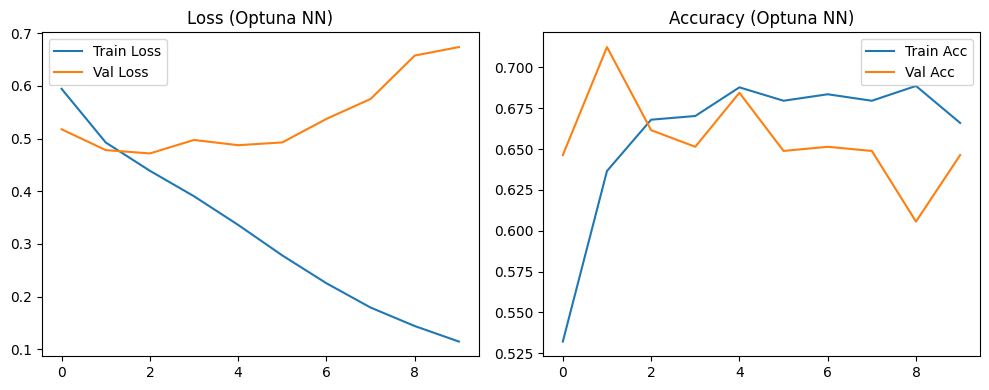

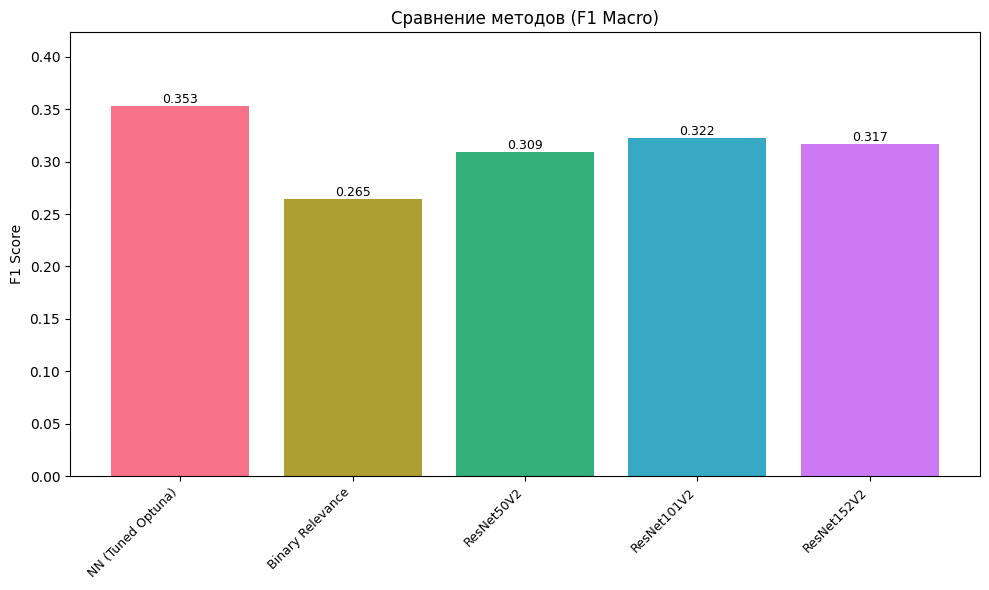

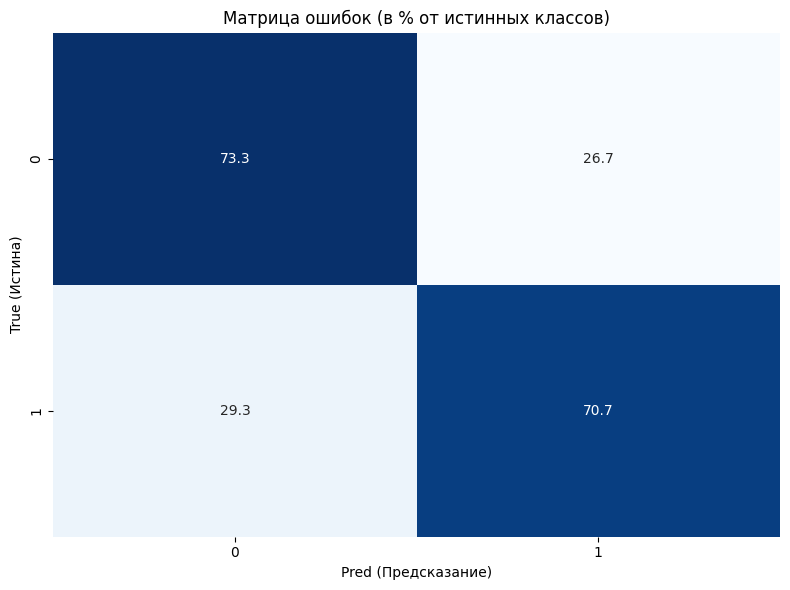

In [15]:
# 5. ВИЗУАЛИЗАЦИЯ

# График обучения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_nn.history['loss'], label='Train Loss')
plt.plot(history_nn.history['val_loss'], label='Val Loss')
plt.title('Loss (Optuna NN)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_nn.history['accuracy'], label='Train Acc')
plt.plot(history_nn.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy (Optuna NN)')
plt.legend()
plt.tight_layout()
plt.show()

# Сравнение методов (Столбчатая диаграмма)
plt.figure(figsize=(10, 6))
palette = sns.color_palette("husl", len(df_res)) # Генерируем нужное кол-во цветов

bars = plt.bar(df_res['Method'], df_res['F1 Macro'], color=palette)
plt.title('Сравнение методов (F1 Macro)')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylim(0, df_res['F1 Macro'].max() * 1.2) # Автоматический отступ сверху

# Добавляем цифры над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Матрица ошибок (Heatmap) 
# Получаем бинарные предсказания (0 или 1)
y_pred_nn_bin = (y_pred_compound_nn > 0.5).astype(int)

# Сводим в плоские векторы (для бинарной классификации: Есть/Нет эмоции)
y_true_flat = y_test_compound_arr.flatten()
y_pred_flat = y_pred_nn_bin.flatten()

# Строим кросстаблицу (счета)
cm = pd.crosstab(y_true_flat, y_pred_flat, rownames=['True (Истина)'], colnames=['Pred (Предсказание)'])

# Нормализуем по строкам (чтобы видеть проценты от истинных классов)
cm_percent = cm.div(cm.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', cbar=False) # .1f = 1 знак после запятой
plt.title('Матрица ошибок (в % от истинных классов)')
plt.tight_layout()
plt.show()

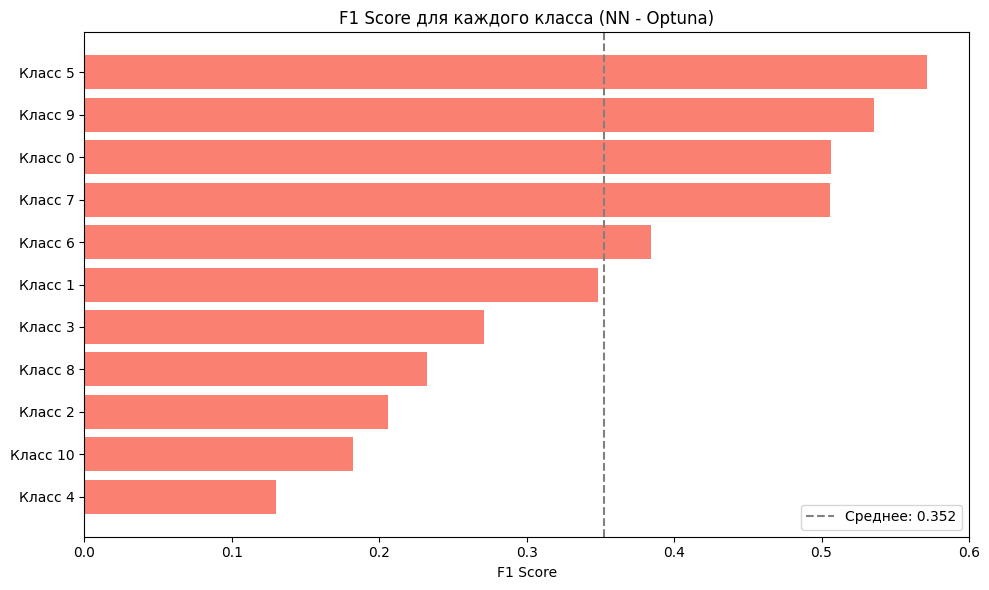

In [16]:
# F1-мера для каждого класса (Глубинный анализ)
# Бинаризация предсказаний 
y_pred_nn_bin = (y_pred_compound_nn > 0.5).astype(int)

# Расчёт F1 для каждого класса отдельно
class_f1 = []
for i in range(y_test_compound_arr.shape[1]):  
    score = f1_score(y_test_compound_arr[:, i], y_pred_nn_bin[:, i], zero_division=0)
    class_f1.append(score)

# Подготовка данных для горизонтального графика
class_names = [f"Класс {i}" for i in range(len(class_f1))]
sorted_indices = np.argsort(class_f1)
sorted_f1 = [class_f1[i] for i in sorted_indices]
sorted_names = [class_names[i] for i in sorted_indices]

# Построение графика
plt.figure(figsize=(10, 6))
plt.barh(sorted_names, sorted_f1, color='salmon')
plt.xlabel('F1 Score')
plt.title('F1 Score для каждого класса (NN - Optuna)')
plt.axvline(x=np.mean(sorted_f1), color='gray', linestyle='--', label=f'Среднее: {np.mean(sorted_f1):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

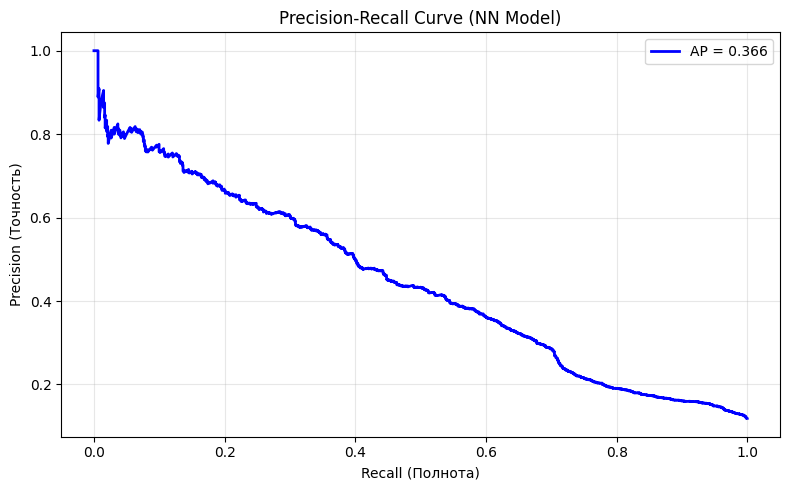

In [17]:
# Precision-Recall Curve (Кривая T-P)
from sklearn.metrics import precision_recall_curve, average_precision_score

# Рассчитываем для лучшего нейрона
precision, recall, _ = precision_recall_curve(y_test_compound_arr.ravel(), y_pred_compound_nn.ravel())
average_precision = average_precision_score(y_test_compound_arr, y_pred_compound_nn)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='blue', linewidth=2, label=f'AP = {average_precision:.3f}')
plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.title('Precision-Recall Curve (NN Model)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

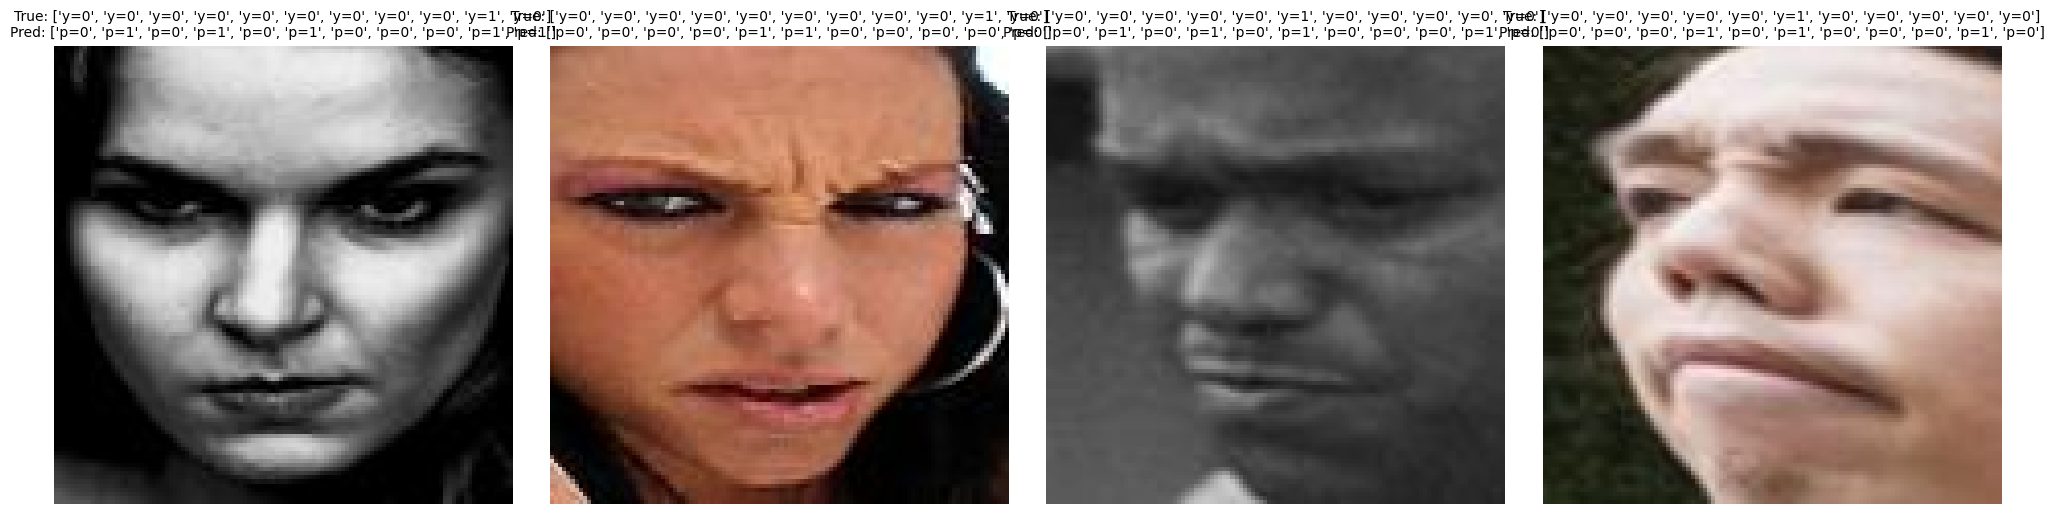

In [18]:
# Примеры предсказаний (Визуальная проверка)
import matplotlib.image as mpimg

# берем первые 4 
indices = [0, 1, 2, 3] 

plt.figure(figsize=(20, 5))

for i, idx in enumerate(indices):
    plt.subplot(1, 4, i+1)
    
    plt.imshow(X_test[idx]) 
    plt.axis('off')
    
    true_labels = [f"y={int(y_test_compound_arr[idx][j])}" for j in range(y_test_compound_arr.shape[1])]
    pred_labels = [f"p={int(y_pred_nn_bin[idx][j])}" for j in range(y_test_compound_arr.shape[1])]
    
    plt.title(f"True: {true_labels}\nPred: {pred_labels}", fontsize=10)

plt.tight_layout()
plt.show()

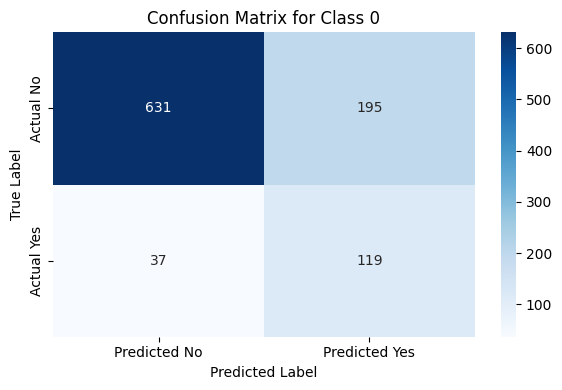

In [19]:
# Матрица ошибок по одному классу (One-vs-Rest)
from sklearn.metrics import confusion_matrix

# Берем предсказания NN
y_pred_nn_bin = (y_pred_compound_nn > 0.5).astype(int)

# Берем 0-й класс (Class 0)
class_idx = 0

cm = confusion_matrix(y_test_compound_arr[:, class_idx], y_pred_nn_bin[:, class_idx])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title(f'Confusion Matrix for Class {class_idx}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()